Decriptive Statistics

In [1]:
#!pip install pandas numpy openpyxl tabulate

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Read Excel file
df = pd.read_excel("demand_dataset.xlsx")

# Select numeric columns only
numeric_df = df.select_dtypes(include=['number'])  # Uncommented this line to define numeric_df

#Step 1: Compute Quantitative Stat Metrics for Numeric Data and Saved Results in Excel

if numeric_df.empty:
    print("No numeric columns found in the Excel file.")

else:
    # Compute descriptive statistics
    mean = numeric_df.mean()
    median = numeric_df.median()
    variance= numeric_df.var()
    std_dev = numeric_df.std()
    minimum = numeric_df.min()
    maximum = numeric_df.max()
    count = numeric_df.count()
    mode = numeric_df.mode().iloc[0]
    kurt = numeric_df.apply(kurtosis)
    skewness = numeric_df.apply(skew)
    percentiles = numeric_df.quantile([0.25, 0.5, 0.75])
    
    # Combine into a single DataFrame
    stats_df = pd.DataFrame({
            "Count": count,
            "Minimum": minimum,
            "Maximum": maximum,
            "Mean": mean,
            "Median": median,
            "Mode": mode,
            "Variance": variance,
            "Standard Deviation": std_dev,      
            "25th Percentile": percentiles.loc[0.25],
            "50th Percentile": percentiles.loc[0.5],
            "75th Percentile": percentiles.loc[0.75],
            "Kurtosis": kurt,
            "Skewness": skewness
            })

In [4]:
# Transpose for readability
stats_df = stats_df.transpose()

In [5]:
# Save the output to a new Excel file
stats_df.to_excel("demand_dataset result.xlsx")

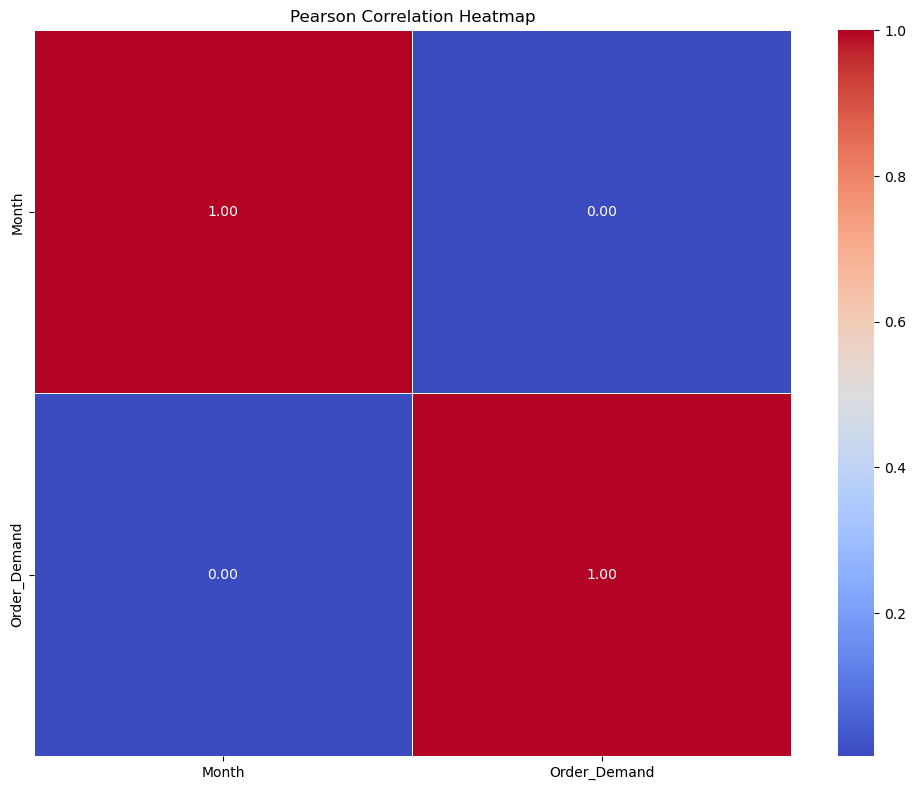

In [6]:
# Step 2: Compute Pearson correlation

correlation_matrix = numeric_df.corr(method='pearson')

# Step 3: Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

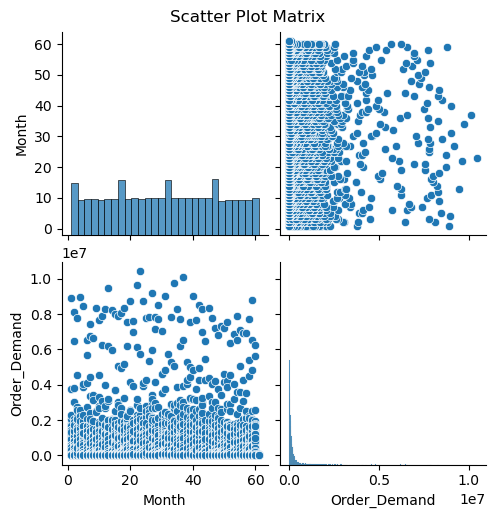

In [7]:
# Step 4: Scatter plot matrix (pairplot)
sns.pairplot(numeric_df)
plt.suptitle('Scatter Plot Matrix', y=1.02)
plt.show()